# Decision Model (의사결정나무) 
: 질문과 선택을 반복해 답을 찾는 모델, 데이터를 나누는 기준을 바탕으로 트리 형태의 구조를 만들어 분류하거나 값을 예측.

## 트리 구성 요소
- Root Node (루트노드) : 트리의 시작점 (ex: "나이는 50세 이상인가?")
- Branch (가지) : 조건에 따라 나뉘는 경로
- Leaf (리프 노드) : 최종 결정

## 분류 방법 
: 데이터를 반복적으로 나누어 같은 그룹에 속하는 데이터가 모이도록 함

**의사결정나무** 는 데이터가 얼마나 깔끔하게 분리되는지(불순도)를 기준으로 결정
- 불순도(Impurity) : 데이터를 섞여있는 정도로 표현
  - 완벽히 분리된 상태 : 불순도 0, 섞여있는 상태 : 불순도 1에 가까움
  - 주요기준 :
    - 지니지수 (Gini Index) : 그룹의 순도를 게산
    - 엔트로피 (Entropy) : 데이터를 나누는 데 필요한 정보량

## 모델의 장/단점
- 장점
  1) 결과를 시각적으로 이해하기 쉬움
  2) 데이터 전처리가 거의 불필요
- 단점
  1) 트리가 너무 깊어지면 학습 데이터에만 맞춰져 과적합 가능성 있음
  2) 데이터가 적을 경우 성능 떨어질 가능성 있음

# 의사결정모델 불순도 판별 기준
## 1. 지니지수 (Gini Index) 
: 그룹의 순도를 측정하는 척도. 값이 작을수록 데이터가 더 깔끔하게 분리되었음을 의미하며, 값이 클수록 데이터가 섞여있음을 나타냄

## 2. 엔트로피 지수 (Entropy)
: 엔트로피는 데이터를 나누기 위해 필요한 정보량을 측정하는 지표이며 값이 작을수록 데이터가 깔끔하게 분리되었음을 나타냄 

## Gini Index vs. Entropy
### Gini Index
: 계산이 간단하며 그룹의 혼합정도를 펴아

### Entropy
:  정보 이론 기반으로 데이터 분리를 위한 정보량을 평가

### 선택 기준
두 지표 모두 데이터 분리의 척도로 사용, 큰 차이가 없다면 간단한 지니 지수를 더 자주 사용

In [2]:
## 모델 실습
### 1. 필요 라이브러리 불러오기
import pandas as pd
from sklearn.model_selection import train_test_split # 데이터 분리
from sklearn.tree import DecisionTreeClassifier # 의사결정나무 모델 생성
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
### 2. 평가지표
import matplotlib.pyplot as plt # 시각화
from sklearn.tree import plot_tree # 의사결정나무 시각화

In [4]:
### 3. 데이터 로드
data = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/heart.csv')

In [6]:
### 4. 입/출력 분리
X = data.drop('output', axis = 1) # output을 제외한 모든 열
y = data['output'] # 심장병 여부

In [7]:
### 5. 데이터를 학습용과 테스트용으로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [12]:
### 6. 모델 생성 및 학습
model = DecisionTreeClassifier(max_depth = 4, random_state = 42) # 트리 깊이 제한
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
### 7. 테스트 데이터로 예측
y_pred = model.predict(X_test)

In [14]:
### 8. 모델 평가
accuracy = accuracy_score(y_test, y_pred) # 정확도 
conf_matrix = confusion_matrix(y_test, y_pred) # 혼동 행렬 계산
report = classification_report(y_test, y_pred) # 정밀도, 재현율, F1 스코어 계산

In [18]:
### 9. 평기 결과 출력
print("Accuaracy : ", accuracy)
print("Confusion Matrix : \n", conf_matrix)
print("Classification Report : \n", report)

Accuaracy :  0.8524590163934426
Confusion Matrix : 
 [[26  3]
 [ 6 26]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



[해석]
precision (정밀도) : 모델이 양성(1)로 에측한 값 중 실제로 양성인 비율
- 클래스 0 : 0.81 -> 81%의 정확도로 클래스 0 예측
- 클래스 1 : 0.90 -> 90%의 정확도로 클래스 1 예측
recall (재현율) : 실제 양성(1) 중에서 모델이 정확히 예측한 비율
- 클래스 0 : 0.90 -> 90%의 재현율로 클래스 0 예측
- 클래스 1 : 0.81 -> 81%의 재현율로 클래스 1 예측
f1-score : precision고 recall의 조화 평균
- 클래스 0 : 0.85 -> 클래스 0 예측의 전반적 성능
- 클래스 1 : 0.85 -> 클래스 1 예측의 전반적 성능
support : 각 클래스의 실제 데이터 개수
- 클래스 0 : 29개, 클래스 1 : 32개
Accuracy (정확도) : 전체 데이터 중 올바르게 예측한 비율 


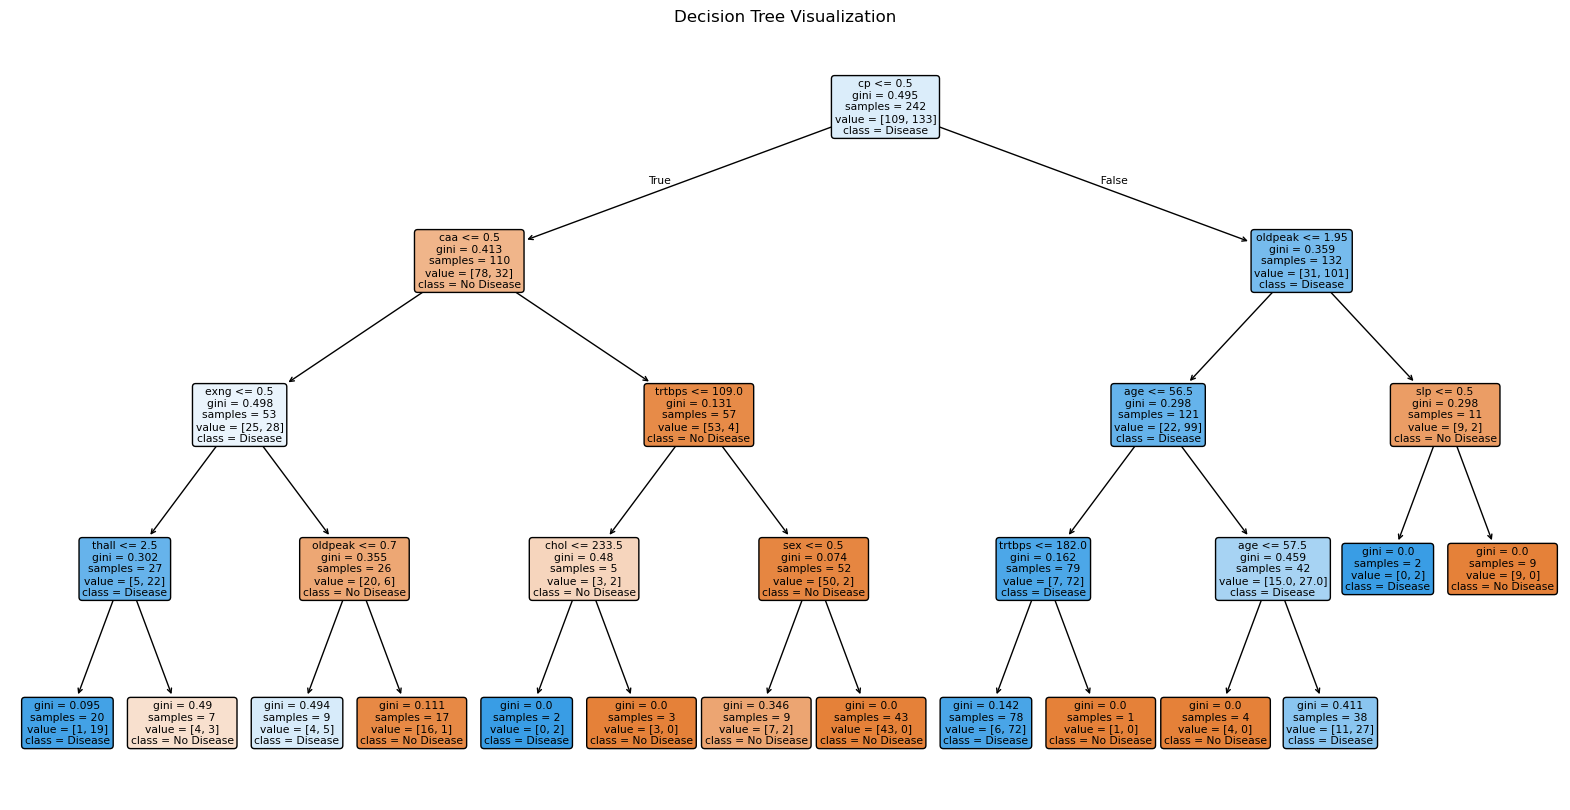

In [17]:
### 10. 의사결정나무 시각화
plt.figure(figsize = (20,10))
plot_tree(model, feature_names = X.columns, class_names = ["No Disease", "Disease"], filled = True, rounded = True)
# tree의 각 노드에 조건, 불순도, 데이터 수 등을 표시. 시각적으로 트리 구조 분석 
plt.title("Decision Tree Visualization")
plt.show()